## **XGBoost Classifier**

## Import Libraries


In [ ]:
# ==========================================================
# Import Libraries
# ==========================================================

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

In [56]:
df = pd.read_csv('main_clean_data.csv')

In [57]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


# Features and Target


In [58]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop('completion_status', axis=1)

y = df['completion_status']

## Train Test Split

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [60]:
# ==========================================================
# XGBoost Classifier
# ==========================================================

start_time = time.time()

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(
    X_train,
    y_train
)

end_time = time.time()

print(
    "Training Time :",
    round(end_time-start_time,3),
    "seconds"
)

Training Time : 0.244 seconds


In [61]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = xgb_clf.predict(
    X_test
)

## XGBoost Accuracy

In [62]:
# ==========================================================
# Accuracy
# ==========================================================

xgb_acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "XGBoost Accuracy :",
    xgb_acc
)

XGBoost Accuracy : 0.8369441277080958


## Classification Report

In [63]:
# ==========================================================
# Classification Report
# ==========================================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87       564
         1.0       0.77      0.77      0.77       313

    accuracy                           0.84       877
   macro avg       0.82      0.82      0.82       877
weighted avg       0.84      0.84      0.84       877



## Confusion Matrix

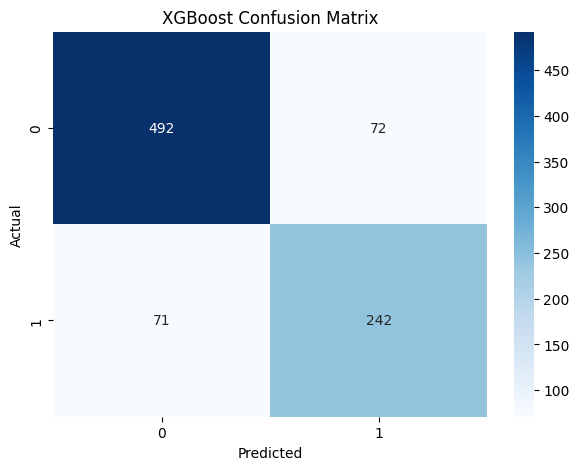

In [64]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC AUC Score


In [65]:
# ==========================================================
# ROC AUC Score
# ==========================================================

from sklearn.metrics import roc_auc_score

# Probability for Positive Class
y_prob = xgb_clf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score :{auc_score:.4f}")

ROC-AUC Score :0.9093


# ROC Curve


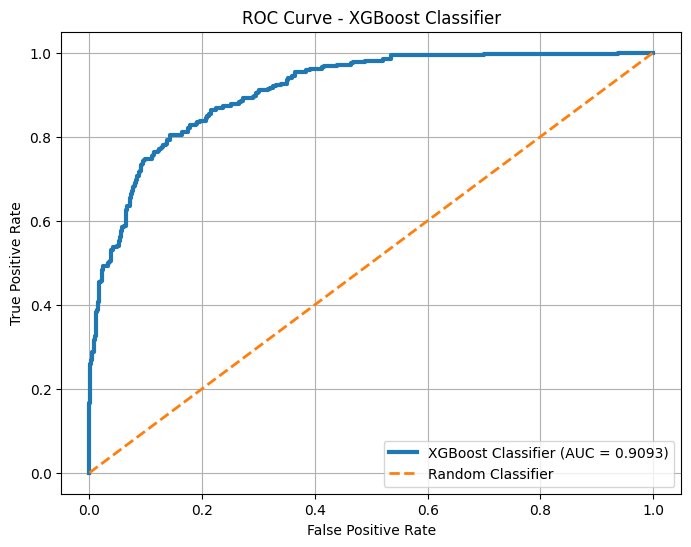

In [66]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'XGBoost Classifier (AUC = {auc_score:.4f})'
)

# Random Classifier Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - XGBoost Classifier"
)

plt.legend()

plt.grid(True)

plt.show()

## **XGBoost Regressor**

## Import Libraries

In [67]:
# ==========================================================
# Import Regressor
# ==========================================================

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Features and Target


In [68]:
# ==========================================================
# Features and Target
# ==========================================================

X = df.drop(
    'final_score',
    axis=1
)

y = df['final_score']

## Train Test Split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [70]:
# ==========================================================
# XGBoost Regressor
# ==========================================================

start_time = time.time()

xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_reg.fit(
    X_train,
    y_train
)

end_time = time.time()

print(
    "Training Time :",
    round(end_time-start_time,3),
    "seconds"
)

Training Time : 0.201 seconds


In [71]:
# ==========================================================
# Prediction
# ==========================================================

y_pred = xgb_reg.predict(
    X_test
)

## Regression Metrics

In [72]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 6.429784012275791
MSE : 64.77828739945933
RMSE : 8.048495971264403
R2 Score : 0.6234345373300793


# Actual vs Predicted


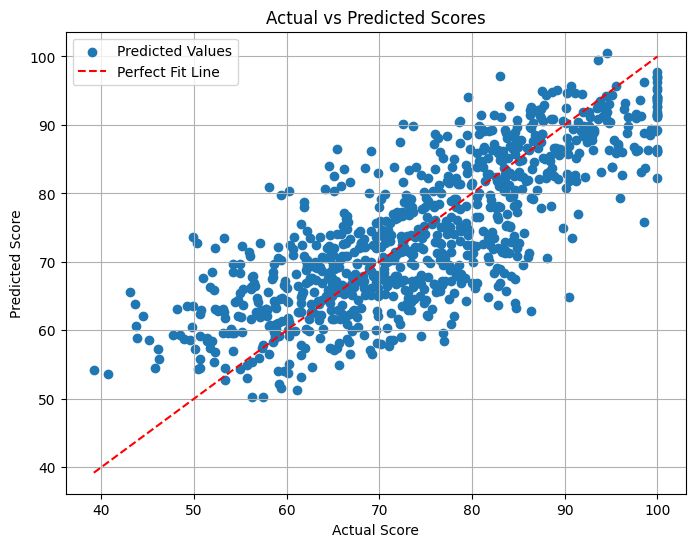

In [73]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    label="Predicted Values"
)

# Perfect Fit Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect Fit Line"
)

plt.xlabel("Actual Score")

plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Scores")

plt.legend()

plt.grid(True)

plt.show()

# XGBoost Classifier Analysis

## Overview

XGBoost (Extreme Gradient Boosting) is one of the most advanced and widely used ensemble learning algorithms. It improves upon traditional Gradient Boosting by incorporating regularization, parallel processing, and optimized tree learning techniques, resulting in high predictive performance and strong generalization capability.

In this project, XGBoost Classifier was implemented to predict student course completion status.

---

## Training Performance

### Training Time

**Training Time = 0.244 Seconds**

The model completed training in less than a quarter of a second, demonstrating excellent computational efficiency while maintaining strong predictive accuracy.

---

## Classification Results

### Accuracy Score

**Accuracy = 83.69%**

The XGBoost Classifier correctly predicted approximately 84 out of every 100 student completion outcomes.

---

## Classification Report

| Class | Precision | Recall | F1-Score |
|---------|---------|---------|---------|
| 0 (Not Completed) | 0.87 | 0.87 | 0.87 |
| 1 (Completed) | 0.77 | 0.77 | 0.77 |

### Macro Average

- Precision: 0.82
- Recall: 0.82
- F1-Score: 0.82

### Weighted Average

- Precision: 0.84
- Recall: 0.84
- F1-Score: 0.84

---

## Interpretation

- The model achieved strong classification performance across both classes.
- Students who did not complete the course were identified with high precision and recall.
- The completed class also demonstrated balanced prediction performance.
- The F1-scores indicate stable and reliable classification capability.
- XGBoost effectively minimized classification errors through advanced boosting techniques.

---

## ROC-AUC Analysis

### ROC-AUC Score

**ROC-AUC = 0.9093**

The ROC-AUC score measures the model's ability to distinguish between completed and non-completed students.

### Interpretation

| AUC Score | Performance |
|------------|------------|
| 0.50 | Poor |
| 0.60 - 0.70 | Fair |
| 0.70 - 0.80 | Good |
| 0.80 - 0.90 | Very Good |
| Above 0.90 | Excellent |

The obtained ROC-AUC score of **0.9093** indicates excellent classification capability and strong class separation performance.

---

## XGBoost Classifier Conclusion

The XGBoost Classifier achieved an accuracy of **83.69%** and an excellent **ROC-AUC score of 0.9093**. Despite its short training time of only **0.244 seconds**, the model delivered strong predictive performance. These results demonstrate that XGBoost is a highly effective classification algorithm for educational outcome prediction.

---

# XGBoost Regressor Analysis

## Overview

XGBoost Regressor applies gradient boosting principles to regression tasks while incorporating regularization techniques that help prevent overfitting and improve model robustness.

The objective was to predict student final scores based on academic and engagement-related features.

---

## Training Performance

### Training Time

**Training Time = 0.201 Seconds**

The model trained very efficiently while maintaining strong predictive accuracy, highlighting XGBoost's optimization capabilities.

---

## Regression Results

| Metric | Value |
|----------|----------|
| MAE | 6.43 |
| MSE | 64.78 |
| RMSE | 8.05 |
| R² Score | 0.6234 |

---

### Mean Absolute Error (MAE)

**MAE = 6.43**

On average, the predicted score differs from the actual score by approximately 6.43 marks.

---

### Mean Squared Error (MSE)

**MSE = 64.78**

The average squared prediction error is relatively low, indicating reliable prediction performance.

---

### Root Mean Squared Error (RMSE)

**RMSE = 8.05**

The model's predictions deviate from actual scores by approximately 8.05 marks on average.

---

### R² Score

**R² Score = 0.6234**

This indicates that approximately **62.34% of the variation in student final scores** is explained by the XGBoost Regressor model.

---

## Interpretation

- The model successfully captured important relationships between features and final scores.
- Prediction errors remained within an acceptable range.
- The R² score demonstrates good explanatory power and predictive capability.
- Regularization helped improve model stability and reduce overfitting.

---

## XGBoost Regressor Conclusion

The XGBoost Regressor achieved an **R² score of 0.6234**, indicating that the model explains approximately **62.34% of the variance** in student final scores. With an **MAE of 6.43** and **RMSE of 8.05**, the model produced reliable score predictions. These results demonstrate the effectiveness of XGBoost for regression-based educational analytics.

---

# Final XGBoost Summary

XGBoost proved to be a highly effective ensemble learning technique for both classification and regression tasks.

### Classification Performance

- Accuracy: **83.69%**
- ROC-AUC Score: **0.9093**
- Weighted F1-Score: **0.84**
- Training Time: **0.244 Seconds**

### Regression Performance

- R² Score: **62.34%**
- MAE: **6.43**
- RMSE: **8.05**
- Training Time: **0.201 Seconds**

### Overall Conclusion

XGBoost delivered strong predictive performance while maintaining fast training speed and excellent model robustness. The classifier achieved a high ROC-AUC score above 0.90, demonstrating excellent class separation capability, while the regressor explained more than 62% of the variation in student scores. Due to its regularization mechanisms, computational efficiency, and strong predictive power, XGBoost remains one of the most reliable boosting algorithms for educational outcome prediction and machine learning applications.